import libraries

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

download data

In [2]:
ticker = ["AAPL", "NVDA", "AMZN", "TSLA", "JPM"]

all_ticker_data = []

for ticker_symbol in ticker:

    ticker_data = yf.download(
        ticker_symbol,
        period="5y",
        auto_adjust=False
    )

    ticker_data.columns = ticker_data.columns.get_level_values(0)

    ticker_data = ticker_data.reset_index()

    ticker_data["Ticker"] = ticker_symbol

    all_ticker_data.append(ticker_data)

df = pd.concat(all_ticker_data, ignore_index=True)

df

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Price,Date,Adj Close,Close,High,Low,Open,Volume,Ticker
0,2021-09-07,152.830887,156.690002,157.259995,154.389999,154.970001,82278300,AAPL
1,2021-09-08,151.289825,155.110001,157.039993,153.979996,156.979996,74420200,AAPL
2,2021-09-09,150.275406,154.070007,156.110001,153.949997,155.490005,57305700,AAPL
3,2021-09-10,145.301056,148.970001,155.479996,148.699997,155.000000,140893200,AAPL
4,2021-09-13,145.866776,149.550003,151.419998,148.750000,150.630005,102404300,AAPL
...,...,...,...,...,...,...,...,...
6270,2026-08-31,356.019989,356.019989,357.769989,354.769989,355.899994,7962900,JPM
6271,2026-09-01,354.950012,354.950012,359.929993,354.119995,355.730011,5079000,JPM
6272,2026-09-02,356.220001,356.220001,361.470001,353.790009,357.549988,5341400,JPM
6273,2026-09-03,362.059998,362.059998,362.850006,356.390015,358.679993,5414200,JPM


In [3]:
df.head()

Price,Date,Adj Close,Close,High,Low,Open,Volume,Ticker
0,2021-09-07,152.830887,156.690002,157.259995,154.389999,154.970001,82278300,AAPL
1,2021-09-08,151.289825,155.110001,157.039993,153.979996,156.979996,74420200,AAPL
2,2021-09-09,150.275406,154.070007,156.110001,153.949997,155.490005,57305700,AAPL
3,2021-09-10,145.301056,148.970001,155.479996,148.699997,155.000000,140893200,AAPL
4,2021-09-13,145.866776,149.550003,151.419998,148.750000,150.630005,102404300,AAPL


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6275 entries, 0 to 6274
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       6275 non-null   datetime64[ns]
 1   Adj Close  6275 non-null   float64       
 2   Close      6275 non-null   float64       
 3   High       6275 non-null   float64       
 4   Low        6275 non-null   float64       
 5   Open       6275 non-null   float64       
 6   Volume     6275 non-null   int64         
 7   Ticker     6275 non-null   object        
dtypes: datetime64[ns](1), float64(5), int64(1), object(1)
memory usage: 392.3+ KB


In [5]:
df.describe()

Price,Date,Adj Close,Close,High,Low,Open,Volume
count,6275,6275.000000,6275.000000,6275.000000,6275.000000,6275.000000,6.275000e+03
mean,2024-03-05 16:53:09.800796928,189.810726,191.990605,194.765830,189.095085,191.963821,1.187565e+08
min,2021-09-07 00:00:00,11.199244,11.227000,11.735000,10.813000,10.971000,3.220500e+06
25%,2022-12-02 00:00:00,132.933250,138.245003,140.049995,136.465004,138.434998,3.471680e+07
50%,2024-03-06 00:00:00,182.187790,183.199997,185.410004,180.660004,183.270004,6.148250e+07
75%,2025-06-06 00:00:00,241.050003,243.154999,247.050003,239.673332,243.514999,1.223256e+08
max,2026-09-04 00:00:00,489.880005,489.880005,498.829987,485.329987,489.880005,1.543911e+09
std,NaN,92.065337,91.622344,93.244009,90.000917,91.663611,1.563363e+08


In [6]:
df.shape

(6275, 8)

In [7]:
df.columns

Index(['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume',
       'Ticker'],
      dtype='object', name='Price')

Question 1 — Overall performance

In [8]:
df1 = df[["Date", "Ticker", "Adj Close"]]
df1.columns = ['date', 'ticker', 'price']
df1


,date,ticker,price
0,2021-09-07,AAPL,152.830887
1,2021-09-08,AAPL,151.289825
2,2021-09-09,AAPL,150.275406
3,2021-09-10,AAPL,145.301056
4,2021-09-13,AAPL,145.866776
...,...,...,...
6270,2026-08-31,JPM,356.019989
6271,2026-09-01,JPM,354.950012
6272,2026-09-02,JPM,356.220001
6273,2026-09-03,JPM,362.059998


In [9]:
df1 = df1.pivot_table(index=['date'], columns='ticker', values=['price'])
df1.columns = [col[1] for col in df1.columns.values]
df1

,AAPL,AMZN,JPM,NVDA,TSLA
date,,,,,
2021-09-07,152.830887,175.464493,140.487900,22.587866,250.973328
2021-09-08,151.289825,176.274994,139.861404,22.265930,251.289993
2021-09-09,150.275406,174.207993,140.470276,22.104456,251.619995
2021-09-10,145.301056,173.457504,138.855469,22.404470,245.423340
2021-09-13,145.866776,172.858505,141.061508,22.079538,247.666672
...,...,...,...,...,...
2026-08-31,316.850006,259.769989,356.019989,220.779999,367.950012
2026-09-01,325.130005,254.919998,354.950012,217.440002,356.089996
2026-09-02,324.959991,254.979996,356.220001,224.410004,357.010010


In [10]:
overall_performance = (df1.iloc[-1] - df1.iloc[0]) / df1.iloc[0]
overall_performance * 100

AAPL    109.362131
AMZN     47.328958
JPM     155.281782
NVDA    919.839600
TSLA     41.082716
dtype: float64

Question 2 — Daily returns

In [11]:
daily_return = df1.pct_change().dropna()
daily_return

,AAPL,AMZN,JPM,NVDA,TSLA
date,,,,,
2021-09-08,-0.010083,0.004619,-0.004459,-0.014253,0.001262
2021-09-09,-0.006705,-0.011726,0.004353,-0.007252,0.001313
2021-09-10,-0.033102,-0.004308,-0.011496,0.013573,-0.024627
2021-09-13,0.003893,-0.003453,0.015887,-0.014503,0.009141
2021-09-14,-0.009562,-0.002074,-0.017453,0.004063,0.002005
...,...,...,...,...,...
2026-08-31,-0.008915,-0.024997,-0.004474,0.014847,0.055054
2026-09-01,0.026132,-0.018670,-0.003005,-0.015128,-0.032233
2026-09-02,-0.000523,0.000235,0.003578,0.032055,0.002584


Question 3 — Volatility

In [12]:
volatility = (
    daily_return.std().round(2)
)


In [13]:
volatility

AAPL    0.02
AMZN    0.02
JPM     0.02
NVDA    0.03
TSLA    0.04
dtype: float64

Question 4 — Moving averages(MA7)

In [14]:
df["MA7"] = (
    df
    .groupby("Ticker")["Adj Close"]
    .transform(
        lambda x:
        x.rolling(7).mean()
    )
)
df

Price,Date,Adj Close,Close,High,Low,Open,Volume,Ticker,MA7
0,2021-09-07,152.830887,156.690002,157.259995,154.389999,154.970001,82278300,AAPL,NaN
1,2021-09-08,151.289825,155.110001,157.039993,153.979996,156.979996,74420200,AAPL,NaN
2,2021-09-09,150.275406,154.070007,156.110001,153.949997,155.490005,57305700,AAPL,NaN
3,2021-09-10,145.301056,148.970001,155.479996,148.699997,155.000000,140893200,AAPL,NaN
4,2021-09-13,145.866776,149.550003,151.419998,148.750000,150.630005,102404300,AAPL,NaN
...,...,...,...,...,...,...,...,...,...
6270,2026-08-31,356.019989,356.019989,357.769989,354.769989,355.899994,7962900,JPM,355.574284
6271,2026-09-01,354.950012,354.950012,359.929993,354.119995,355.730011,5079000,JPM,356.055716
6272,2026-09-02,356.220001,356.220001,361.470001,353.790009,357.549988,5341400,JPM,356.031429
6273,2026-09-03,362.059998,362.059998,362.850006,356.390015,358.679993,5414200,JPM,356.798571


Question 4 — Moving averages(MA30)

In [15]:
df["MA30"] = (
    df
    .groupby("Ticker")["Adj Close"]
    .transform(
        lambda x:
        x.rolling(30).mean()
    )
)
df

Price,Date,Adj Close,Close,High,Low,Open,Volume,Ticker,MA7,MA30
0,2021-09-07,152.830887,156.690002,157.259995,154.389999,154.970001,82278300,AAPL,NaN,NaN
1,2021-09-08,151.289825,155.110001,157.039993,153.979996,156.979996,74420200,AAPL,NaN,NaN
2,2021-09-09,150.275406,154.070007,156.110001,153.949997,155.490005,57305700,AAPL,NaN,NaN
3,2021-09-10,145.301056,148.970001,155.479996,148.699997,155.000000,140893200,AAPL,NaN,NaN
4,2021-09-13,145.866776,149.550003,151.419998,148.750000,150.630005,102404300,AAPL,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
6270,2026-08-31,356.019989,356.019989,357.769989,354.769989,355.899994,7962900,JPM,355.574284,355.854331
6271,2026-09-01,354.950012,354.950012,359.929993,354.119995,355.730011,5079000,JPM,356.055716,356.178332
6272,2026-09-02,356.220001,356.220001,361.470001,353.790009,357.549988,5341400,JPM,356.031429,356.445332
6273,2026-09-03,362.059998,362.059998,362.850006,356.390015,358.679993,5414200,JPM,356.798571,356.850665


Question 4 — Moving averages(MA90)

In [16]:
df["MA90"] = (
    df
    .groupby("Ticker")["Adj Close"]
    .transform(
        lambda x:
        x.rolling(90).mean()
    )
)
df

Price,Date,Adj Close,Close,High,Low,Open,Volume,Ticker,MA7,MA30,MA90
0,2021-09-07,152.830887,156.690002,157.259995,154.389999,154.970001,82278300,AAPL,NaN,NaN,NaN
1,2021-09-08,151.289825,155.110001,157.039993,153.979996,156.979996,74420200,AAPL,NaN,NaN,NaN
2,2021-09-09,150.275406,154.070007,156.110001,153.949997,155.490005,57305700,AAPL,NaN,NaN,NaN
3,2021-09-10,145.301056,148.970001,155.479996,148.699997,155.000000,140893200,AAPL,NaN,NaN,NaN
4,2021-09-13,145.866776,149.550003,151.419998,148.750000,150.630005,102404300,AAPL,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
6270,2026-08-31,356.019989,356.019989,357.769989,354.769989,355.899994,7962900,JPM,355.574284,355.854331,329.460391
6271,2026-09-01,354.950012,354.950012,359.929993,354.119995,355.730011,5079000,JPM,356.055716,356.178332,329.956589
6272,2026-09-02,356.220001,356.220001,361.470001,353.790009,357.549988,5341400,JPM,356.031429,356.445332,330.504617
6273,2026-09-03,362.059998,362.059998,362.850006,356.390015,358.679993,5414200,JPM,356.798571,356.850665,331.080479


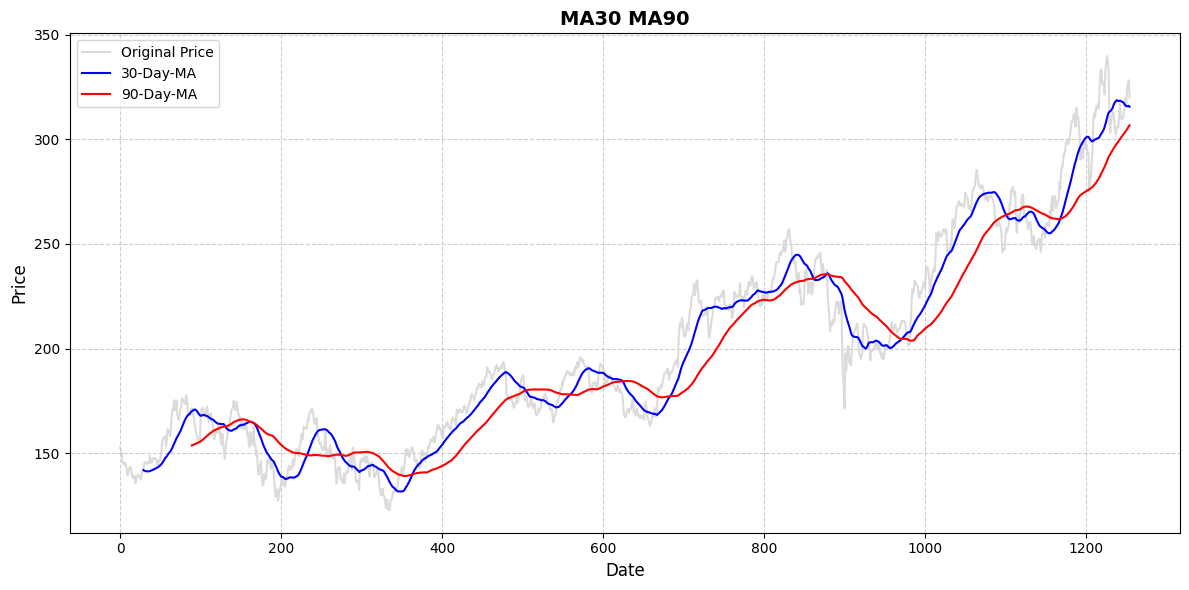

In [17]:
aapl = df[
    df["Ticker"] == "AAPL"
]

plt.figure(figsize=(12,6))

plt.plot(aapl["Adj Close"], label="Original Price", color="lightgray", alpha=0.8)
plt.plot(aapl["MA30"], label="30-Day-MA", color="blue", linewidth=1.5)
plt.plot(aapl["MA90"], label="90-Day-MA", color="red", linewidth=1.5)

plt.title("MA30 MA90", fontsize=14, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()

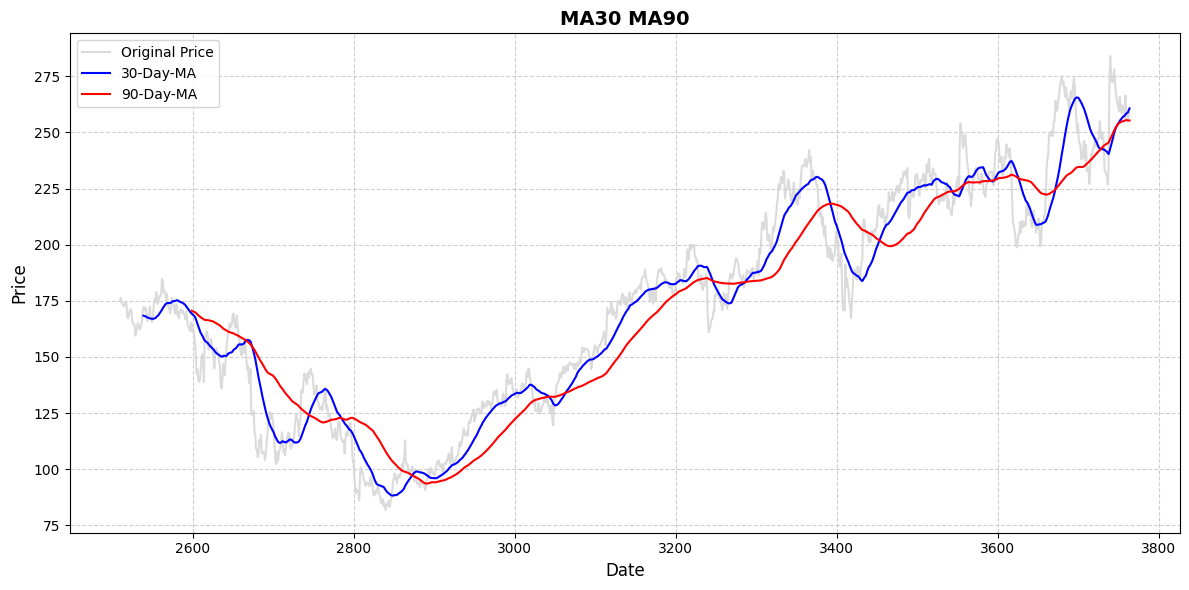

In [18]:
amzn = df[
    df["Ticker"] == "AMZN"
]

plt.figure(figsize=(12,6))

plt.plot(amzn["Adj Close"], label="Original Price", color="lightgray", alpha=0.8)
plt.plot(amzn["MA30"], label="30-Day-MA", color="blue", linewidth=1.5)
plt.plot(amzn["MA90"], label="90-Day-MA", color="red", linewidth=1.5)

plt.title("MA30 MA90", fontsize=14, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()

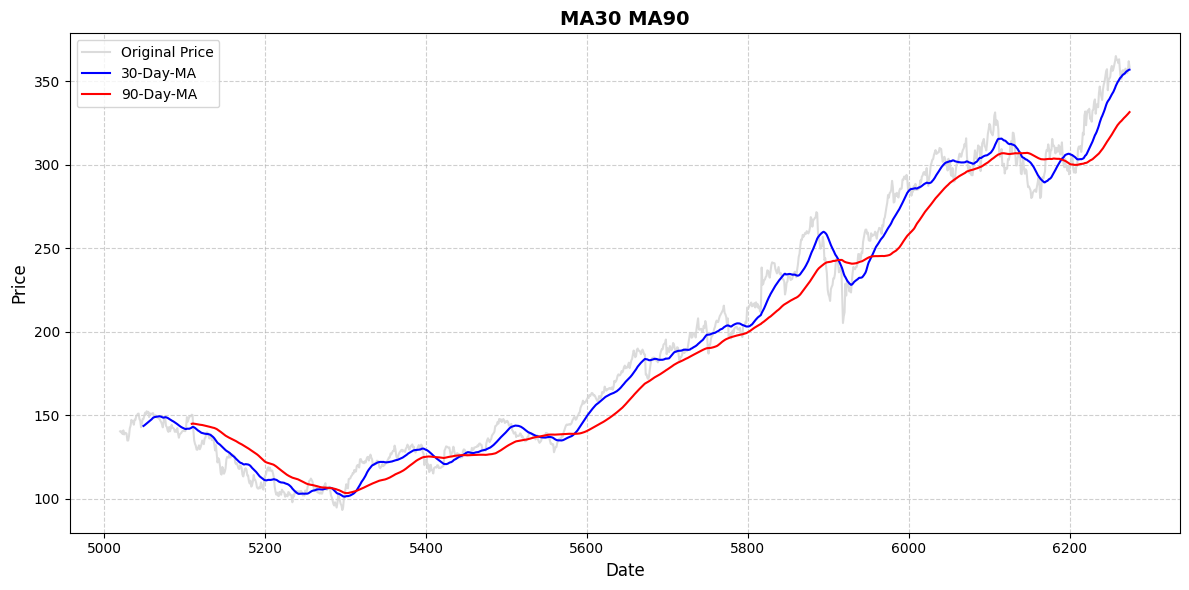

In [19]:
jpm = df[
    df["Ticker"] == "JPM"
]

plt.figure(figsize=(12,6))

plt.plot(jpm["Adj Close"], label="Original Price", color="lightgray", alpha=0.8)
plt.plot(jpm["MA30"], label="30-Day-MA", color="blue", linewidth=1.5)
plt.plot(jpm["MA90"], label="90-Day-MA", color="red", linewidth=1.5)

plt.title("MA30 MA90", fontsize=14, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()

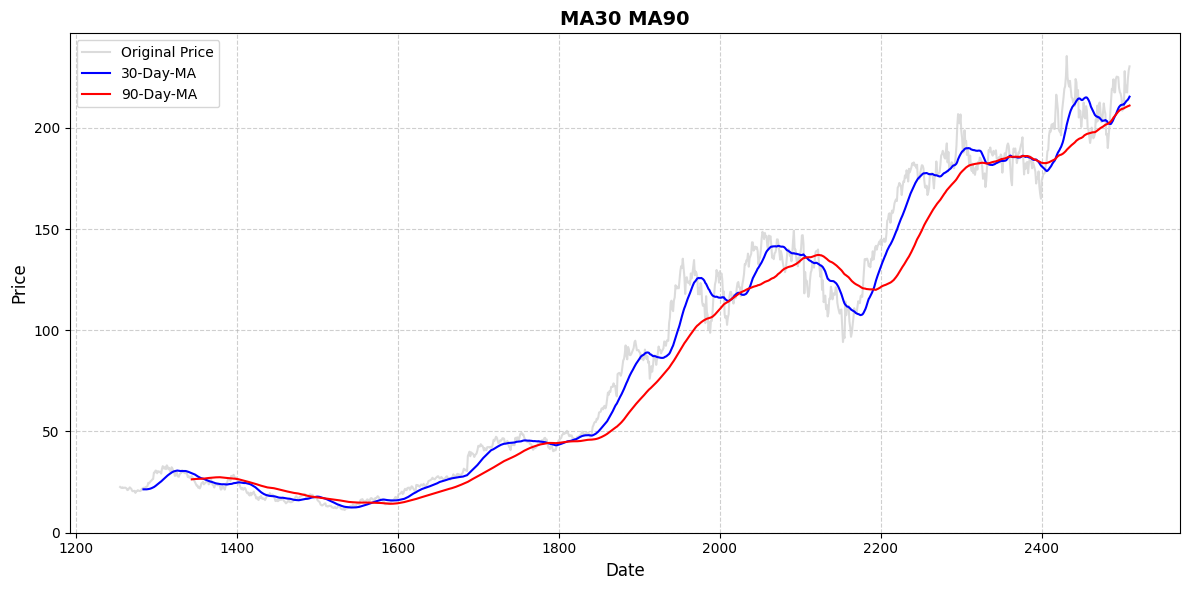

In [20]:
nvda = df[
    df["Ticker"] == "NVDA"
]

plt.figure(figsize=(12,6))

plt.plot(nvda["Adj Close"], label="Original Price", color="lightgray", alpha=0.8)
plt.plot(nvda["MA30"], label="30-Day-MA", color="blue", linewidth=1.5)
plt.plot(nvda["MA90"], label="90-Day-MA", color="red", linewidth=1.5)

plt.title("MA30 MA90", fontsize=14, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()

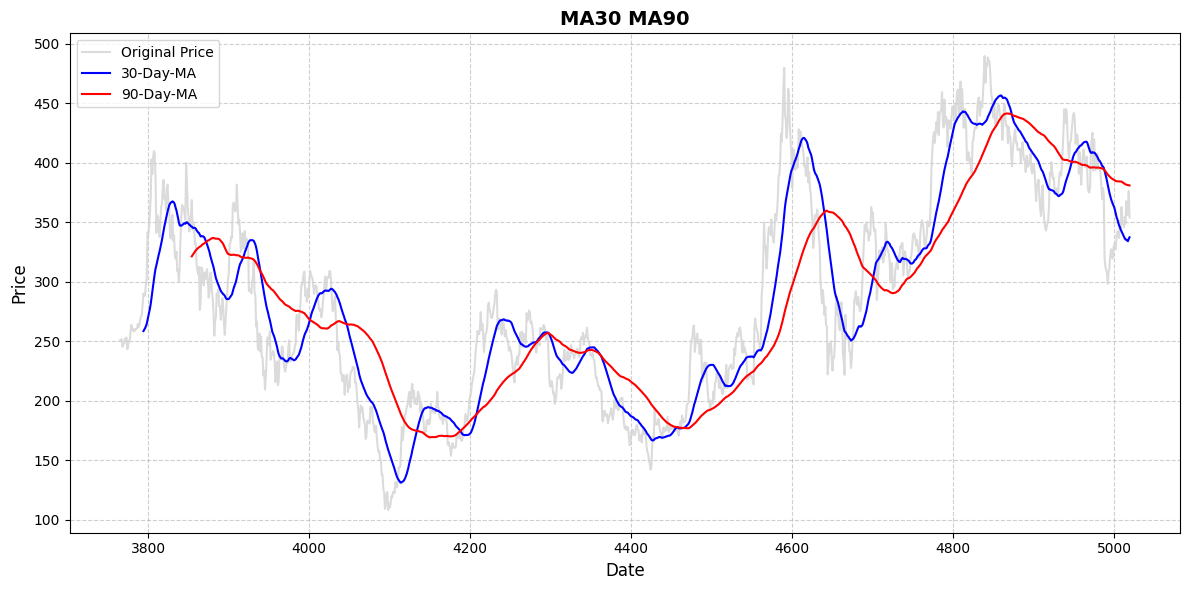

In [21]:
tsla = df[
    df["Ticker"] == "TSLA"
]

plt.figure(figsize=(12,6))

plt.plot(tsla["Adj Close"], label="Original Price", color="lightgray", alpha=0.8)
plt.plot(tsla["MA30"], label="30-Day-MA", color="blue", linewidth=1.5)
plt.plot(tsla["MA90"], label="90-Day-MA", color="red", linewidth=1.5)

plt.title("MA30 MA90", fontsize=14, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()

Question 5 — Best and worst days

In [23]:
top10_gain = df1.nlargest(10)
top10_gain

TypeError: DataFrame.nlargest() missing 1 required positional argument: 'columns'